In [338]:
# from src.MPOptoClass import *
from src.utils.gen_utils import *
from src.utils.filters import *
from src.experiment import *
from src.wiener_filter import *
from src.modeller import *
from src.MPRecordClass import *
from src.ReachingClass import *
from src.analysis import *
import scipy
import copy
import time
import mat73 
import pynapple as nap
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colormaps
import random
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from itertools import permutations, compress, product
from tqdm import tqdm




%load_ext autoreload 
%autoreload 2
%matplotlib widget

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# all check

In [767]:
output = pload('/home/diya/Documents/mp_opto/picklejar/coSweepRegsAll_20nlag_50post_50sw.pickle')
asymps = pload('/home/diya/Documents/mp_opto/picklejar/coSweepRegsAllasymps_20nlag_50post_50sw.pickle')

In [768]:
cc_r2 = []
cl_r2 = []
c_ratio = []
c_hlist = []

swc_r2=[]
swl_r2=[]
sw_ratio=[]
sw_hlist=[]

cwc_r2=[]
cwl_r2=[]
cw_ratio=[]
cw_hlist=[]

lc_r2 = []
ll_r2=[]
l_ratio=[]
l_hlist=[]

#4, 
sesh=2

regs=[]

c_pos_asymps = asymps[sesh][0][0]
sw_pos_asymps = asymps[sesh][0][1]
cw_pos_asymps = asymps[sesh][0][2]
l_pos_asymps = asymps[sesh][0][3]

X_l = asymps[sesh][2][0]
X_c = asymps[sesh][2][1]

Y_l = asymps[sesh][3][0]
Y_c = asymps[sesh][3][1]

session_name = output[sesh][0][4][1]
inact = output[sesh][0][4][2]

animal = session_name.split('_')[0]
session_path = f'../data/co/{animal}/{session_name}'
session = MPOptoClass(session_path)
print(session_name)
print(inact)
for run in output[sesh]:
    
    c=run[0]
    sw=run[1]
    cw = run[2]
    l = run[3]
    
    regs.append(run[2][0])
    
    c_hlist.append(c[0])
    cl_r2.append(c[1])
    cc_r2.append(c[2])
    d, u = session.weights_per_region(c_hlist[-1], nlags=20, num_region1=20)
    c_ratio.append(np.log10(d/u))
    
    sw_hlist.append(sw[0])
    swl_r2.append(sw[1])
    swc_r2.append(sw[2])
    d, u = session.weights_per_region(sw_hlist[-1], nlags=20, num_region1=20)
    sw_ratio.append(np.log10(d/u))
    
    cw_hlist.append(cw[0])
    cwl_r2.append(cw[1])
    cwc_r2.append(cw[2])
    d, u = session.weights_per_region(cw_hlist[-1], nlags=20, num_region1=20)
    cw_ratio.append(np.log10(d/u))
    
    l_hlist.append(l[0])
    ll_r2.append(l[1])
    lc_r2.append(l[2])
    d, u = session.weights_per_region(l_hlist[-1], nlags=20, num_region1=20)
    l_ratio.append(np.log10(d/u))



love
co10_01242024
RFA


/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


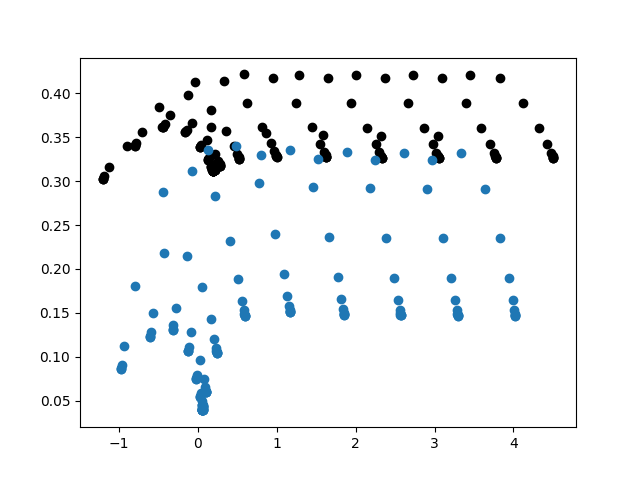

In [769]:
fig, ax = plt.subplots()
ax.scatter(c_ratio, cc_r2, color='black')
ax.scatter(sw_ratio, swc_r2, color='tab:blue')

In [770]:
ctop_ratio, ctop_r2, cidxs, cedges = get_top_models(c_ratio, cl_r2, num_bins=15)
swtop_ratio, swtop_r2, swidxs, _ = get_top_models(sw_ratio, swl_r2, num_bins=15)
cwtop_ratio, cwtop_r2, cwidxs, _ = get_top_models(cw_ratio, cwl_r2, num_bins=15)
ltop_ratio, ltop_r2, lidxs, _ = get_top_models(l_ratio, ll_r2, num_bins=15)

cmax = np.argmax(ctop_r2)
swmax = np.argmax(swtop_r2)
cwmax = np.argmax(cwtop_r2)
lmax = np.argmax(ltop_r2)

[-1.2059332  -0.48810567 -0.06875178  0.28786187  0.52783711  0.99843049
  1.44491054  1.62879235  2.14580785  2.33079641  2.97572868  3.05289974
  3.70199314  3.77918687  4.50597138]
[-0.79211079 -0.42694484 -0.07601322  0.21307984  0.48981605  0.7814663
  1.17023779  1.46357863  1.88722198  2.181067    2.61249028  2.90644216
  3.33938461  3.6333564   3.83202484]
[-0.78027366 -0.29878654 -0.12972775  0.22151145  0.416317    0.98408275
  1.09301771  1.66442543  1.77466674  2.17971833  2.38130262  2.90479001
  3.10654531  3.63164661  3.83343434]
[-3.04017413 -2.1620715  -1.71020573 -0.82698387 -0.41551562  0.16520814
  0.84733273  1.22195476  1.94001657  2.66550913  3.39244639  4.11965616
  4.84691709  5.57418761  5.88858284]


/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


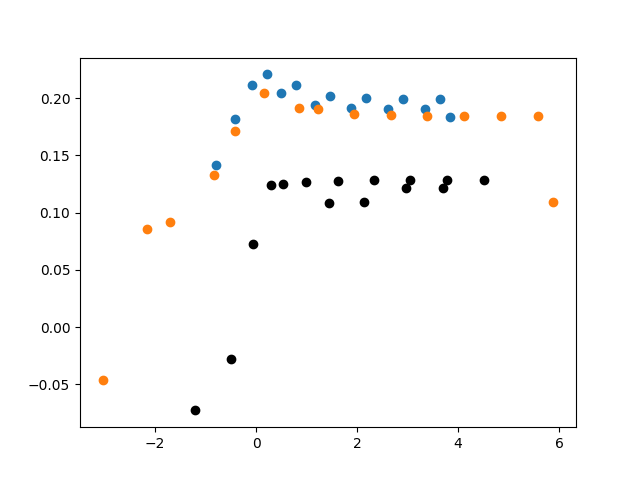

In [771]:
fig, ax = plt.subplots()
ax.scatter(ctop_ratio, ctop_r2, color='black')
ax.scatter(swtop_ratio, swtop_r2, color='tab:blue')
ax.scatter(ltop_ratio, ltop_r2, color='tab:orange')
#@ax.set_xlim(-2,4)

In [772]:
c_harray, cw_harray, sw_harray, l_harray= squeezer(c_hlist, cw_hlist, sw_hlist, l_hlist)
c_harray = c_harray[cidxs,:,:]
cw_harray = cw_harray[cwidxs,:,:]
l_harray = l_harray[lidxs,:,:]
sw_harray = sw_harray[swidxs,:,:]

#h0 = c_harray[cmax,:,:]
h1 = c_harray[swmax,:,:]
#h1 = cw_harray[2,:,:]
h2 = sw_harray[swmax,:,:]

In [773]:
nlags=20
varz = np.var(Y_l, axis=0)
h1_col = collapse_h(h1, nlags=nlags, var=varz, bias=True)
h2_col = collapse_h(h2, nlags=nlags, var=varz, bias=True)

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


Text(0.5, 0, 'PCs')

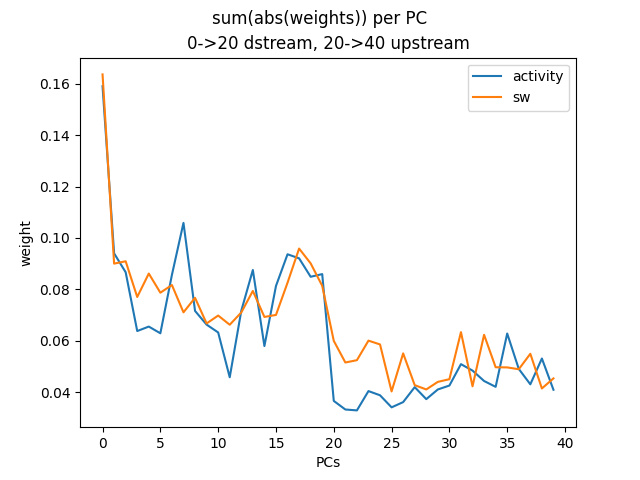

In [774]:
fig, ax = plt.subplots()
ax.plot(h1_col, label=f'activity')
ax.plot(h2_col, label=f'sw')
ax.legend()
fig.suptitle('sum(abs(weights)) per PC')
ax.set_title('0->20 dstream, 20->40 upstream')
ax.set_ylabel('weight')
ax.set_xlabel('PCs')

In [775]:
varz = np.var(Y_l, axis=0)
h1_col = collapse_h_lags(h1, nlags=nlags, var=varz, bias=True)
h2_col = collapse_h_lags(h2, nlags=nlags, var=varz, bias=True)

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


Text(0.5, 0, 'lag')

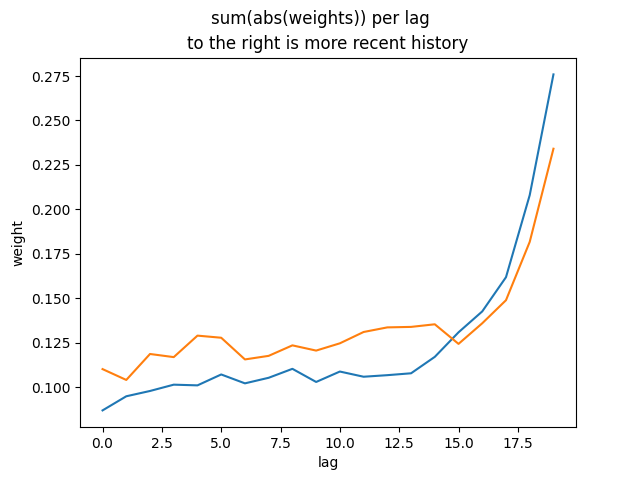

In [776]:
fig, ax = plt.subplots()
ax.plot(h1_col)
ax.plot(h2_col)
fig.suptitle('sum(abs(weights)) per lag')
ax.set_title('to the right is more recent history')
ax.set_ylabel('weight')
ax.set_xlabel('lag')

In [777]:
hs = sw_harray[swmax:,1:,0]
#h_concat = np.reshape(hs, (8, 801))
h_PCAobj = PCA(n_components=8)
h_PCA = h_PCAobj.fit_transform(hs)
print(hs.shape)

(12, 800)


/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


Text(0.5, 0, 'PCs')

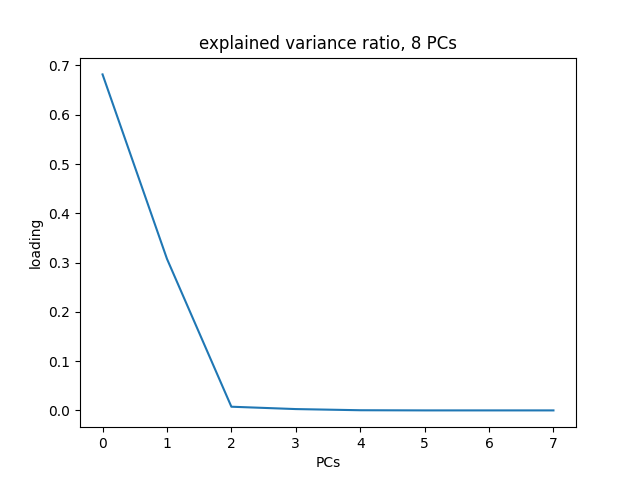

In [778]:
fig, ax = plt.subplots()
ax.plot(h_PCAobj.explained_variance_ratio_)
ax.set_title('explained variance ratio, 8 PCs')
ax.set_ylabel('loading')
ax.set_xlabel('PCs')

In [779]:
#hs = c_harray[cmax:,1:,0]
hs = c_harray[7:,1:,0]
#h_concat = np.reshape(hs, (8, 801))
h_PCAobj = PCA(n_components=8)
h_PCA = h_PCAobj.fit_transform(hs)
print(hs.shape)

(8, 800)


/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


Text(0.5, 0, 'PCs')

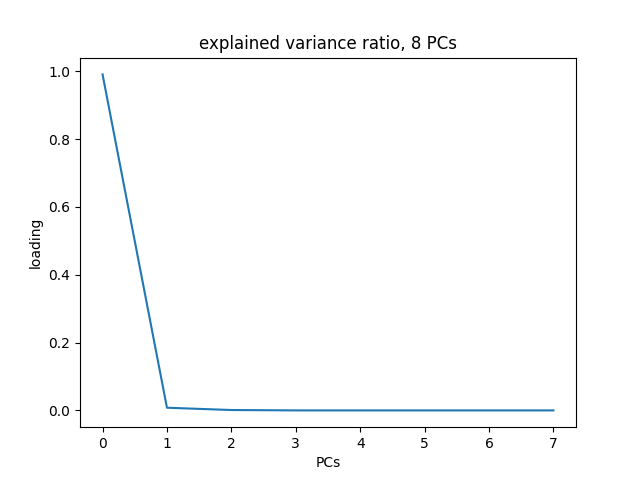

In [780]:
fig, ax = plt.subplots()
ax.plot(h_PCAobj.explained_variance_ratio_)
ax.set_title('explained variance ratio, 8 PCs')
ax.set_ylabel('loading')
ax.set_xlabel('PCs')

# plot trial averaged data

In [781]:
pre=100
post=50
binsize=5
nlags=20
num_PCs=20



laser_bounds, ctrl_bounds = session.adjustLaserBounds(pre, post, only_climb=True)
(X, Y), PCs = session.generate_trainset(bounds=session.climbing_bounds, binsize=binsize, nlags=nlags, num_PCs=num_PCs)
X_laser, Y_laser = session.generate_testset(PCs, laser_bounds, binsize=binsize, nlags=nlags, num_PCs=num_PCs)
X_ctrl, Y_ctrl = session.generate_testset(PCs, ctrl_bounds, binsize=binsize, nlags=nlags, num_PCs=num_PCs)

In [782]:
h_sw = sw_harray[swmax,:,:]
h_c = c_harray[cmax,:,:]
h_l = l_harray[lmax,:,:]

In [783]:
yhat_l1, yhat_l2 = split_h_predics(X_laser, h_sw, nlags=nlags, num_region1=20)
yhat_c1, yhat_c2 = split_h_predics(X_ctrl, h_sw, nlags=nlags, num_region1=20)

this h has bias
this h has bias


In [784]:
yhat_l1_reshape = np.reshape(yhat_l1, (int(yhat_l1.shape[0]/15),15, yhat_l1.shape[1]))
yhat_l2_reshape = np.reshape(yhat_l2, (int(yhat_l2.shape[0]/15),15, yhat_l2.shape[1]))
ylaser_reshape = np.reshape(Y_laser, (int(Y_laser.shape[0]/15),15, Y_laser.shape[1]))


In [785]:
yhat1_avg = np.average(yhat_l1_reshape, axis=0)
yhat2_avg = np.average(yhat_l2_reshape, axis=0)
ylaser_avg = np.average(ylaser_reshape, axis=0)

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


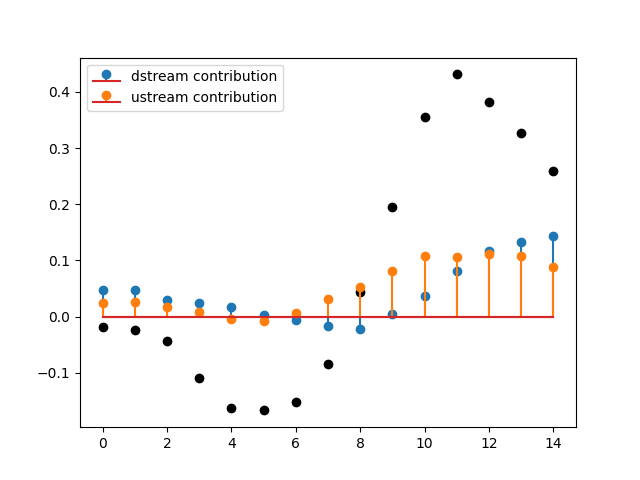

In [786]:
fig, ax = plt.subplots()
ax.stem(np.arange(15), yhat1_avg[:,0], label='dstream contribution')
ax.stem(np.arange(15), yhat2_avg[:,0], linefmt='tab:orange', label='ustream contribution')
ax.scatter(np.arange(15), ylaser_avg[:,0], color='black')
ax.legend()

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


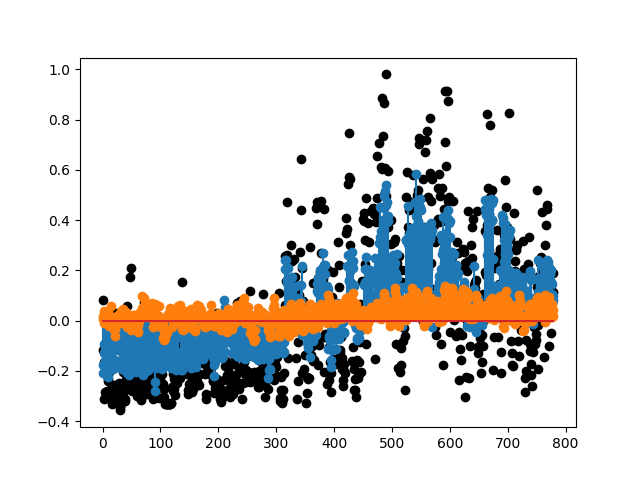

In [787]:
fig, ax = plt.subplots()
ax.stem(np.arange(yhat_c1.shape[0]), yhat_c1[:,0])
ax.stem(np.arange(yhat_c2.shape[0]), yhat_c2[:,0], linefmt='tab:orange')
ax.scatter(np.arange(Y_ctrl.shape[0]), Y_ctrl[:,0], color='black')

/tmp/ipykernel_6321/2325927372.py:1: RuntimeWarning: invalid value encountered in log10
  yhat_lratio = np.log10(np.divide(yhat_l1, yhat_l2))
/tmp/ipykernel_6321/2325927372.py:2: RuntimeWarning: invalid value encountered in log10
  yhat_cratio = np.log10(np.divide(yhat_c1, yhat_c2))
/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


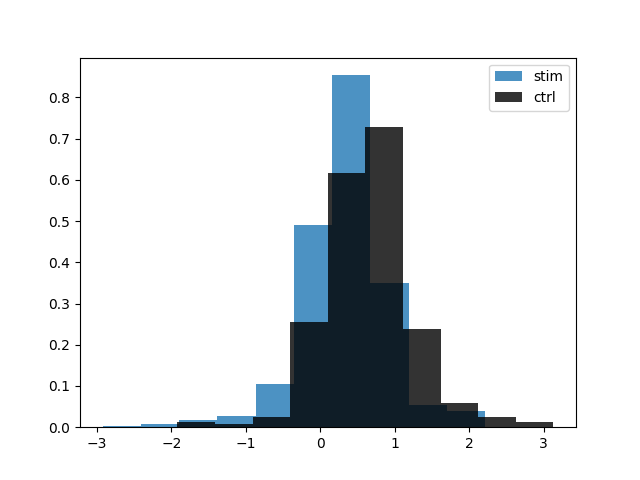

In [788]:
yhat_lratio = np.log10(np.divide(yhat_l1, yhat_l2))
yhat_cratio = np.log10(np.divide(yhat_c1, yhat_c2))
fig, ax = plt.subplots()
ax.hist(yhat_lratio[:,0], color='tab:blue', label='stim', alpha=.8, density=True)
ax.hist(yhat_cratio[:,0], color='black', label='ctrl', alpha=.8, density=True)
ax.legend()

# TO stuff

In [749]:
output = pload('/home/diya/Documents/mp_opto/picklejar/toSweepRegsSW_20nlag_50post_50sw.pickle')
asymps = pload('/home/diya/Documents/mp_opto/picklejar/toSweepRegsSWasymps_20nlag_50post_50sw.pickle')
loutput = pload('/home/diya/Documents/mp_opto/picklejar/toSweepRegsLaser_20nlag_50post.pickle')

# load

In [750]:
cc_r2 = []
c_ratio = []
cl_r2=[]

swc_r2 = []
sw_ratio = []
swl_r2=[]

lc_r2=[]
ll_r2=[]
l_ratio =[]

c_hlist =[]
sw_hlist = []
l_hlist = []

sesh=1

regs=[]

c_asymps = asymps[sesh][0][0]

sw_asymps = asymps[sesh][0][1]

X_l = asymps[sesh][2][0]
X_c = asymps[sesh][2][1]

Y_l = asymps[sesh][3][0]
Y_c = asymps[sesh][3][1]

session_name = output[sesh][0][2][1]
session_check = loutput[sesh][0][3][1]
assert session_name==session_check, 'issue!'
inact = output[sesh][0][2][2]



animal = session_name.split('_')[0]
session_path = f'../data/to/{animal}/{session_name}'
session = MPOptoClass(session_path)
print(session_name)

for idx, run in enumerate(output[sesh]):
    c=run[0]
    sw=run[1]
    l = loutput[sesh][idx][0]
    
   
    c_hlist.append(c[0])
    d, u = session.weights_per_region(c_hlist[-1], nlags=20, num_region1=20)
    c_ratio.append(np.log10(d/u))
    cl_r2.append(c[1])
    cc_r2.append(c[2])
    
    sw_hlist.append(sw[0])
    d, u = session.weights_per_region(sw_hlist[-1], nlags=20, num_region1=20)
    sw_ratio.append(np.log10(d/u))
    swl_r2.append(sw[1])
    swc_r2.append(sw[2])
    
    l_hlist.append(l[0])
    d, u = session.weights_per_region(l_hlist[-1], nlags=20, num_region1=20)
    l_ratio.append(np.log10(d/u))
    ll_r2.append(l[1])
    lc_r2.append(l[2])
    

masking THAL, 300<x<1000
love
to5_06202024


In [751]:
ctop_ratio, ctop_r2, cidxs, cedges = get_top_models(c_ratio, cc_r2, num_bins=15)
swtop_ratio, swtop_r2, swidxs, _ = get_top_models(sw_ratio, swc_r2, num_bins=15)
ltop_ratio, ltop_r2, lidxs, _ = get_top_models(l_ratio, lc_r2, num_bins=15)
cmax = np.argmax(ctop_r2)
swmax = np.argmax(swtop_r2)
lmax = np.argmax(ltop_r2)

[-0.54659849 -0.20567364  0.05312712  0.53978105  0.75606855  1.17226449
  1.39944487  1.87436463  2.10517912  2.5964716   2.82808168  3.32275714
  3.55452304  4.0498443   4.28163955]
[-0.66494872 -0.28923786  0.0114916   0.29575806  0.60153342  0.83703523
  1.28886954  1.69541435  2.007094    2.24627841  2.42059905  2.73258611
  3.14747634  3.45952223  3.69893001]
[-2.78022347 -2.32512306 -1.44160057 -0.62696447 -0.26119109  0.34987645
  0.67462304  1.37030041  2.09095029  2.81694992  3.54398274  4.27121048
  4.99847478  5.39858828  5.72574593]


/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


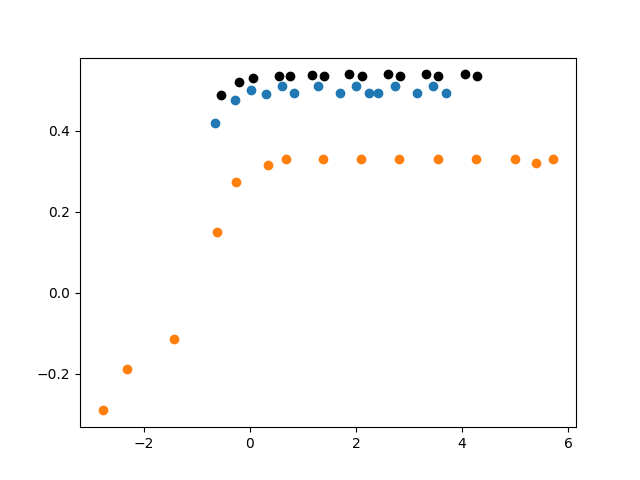

In [752]:
fig, ax = plt.subplots()
ax.scatter(ctop_ratio, ctop_r2, color='black')
ax.scatter(swtop_ratio, swtop_r2, color='tab:blue')
ax.scatter(ltop_ratio, ltop_r2, color='tab:orange')
#@ax.set_xlim(-2,4)

In [753]:
c_harray, sw_harray, l_harray = squeezer(c_hlist, sw_hlist, l_hlist)
c_harray = c_harray[cidxs,:,:]
sw_harray = sw_harray[swidxs,:,:]
l_harray = l_harray[lidxs,:,:]

h1 = c_harray[swmax,:,:]
h2 = sw_harray[swmax,:,:]
#h3 = l_harray[lmax,:,:]

In [754]:
nlags=20
varz = np.var(Y_l, axis=0)
h1_col = collapse_h(h1, nlags=nlags, var=varz, bias=True)
h2_col = collapse_h(h2, nlags=nlags, var=varz, bias=True)

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


Text(0.5, 0, 'PCs')

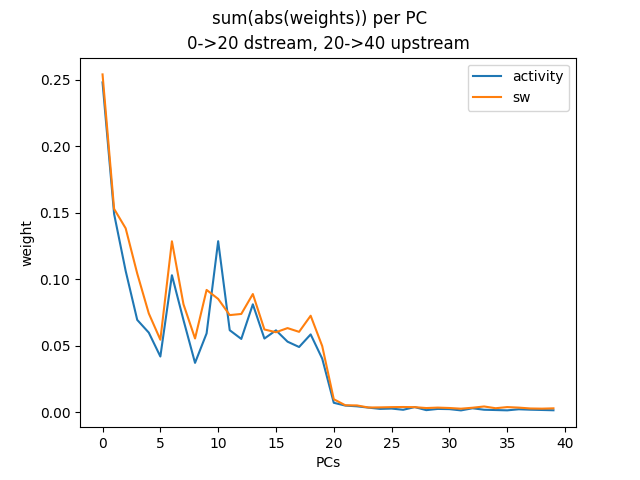

In [755]:
fig, ax = plt.subplots()
ax.plot(h1_col, label=f'activity')
ax.plot(h2_col, label=f'sw')
ax.legend()
fig.suptitle('sum(abs(weights)) per PC')
ax.set_title('0->20 dstream, 20->40 upstream')
ax.set_ylabel('weight')
ax.set_xlabel('PCs')

In [756]:
varz = np.var(Y_l, axis=0)
h1_col = collapse_h_lags(h1, nlags=nlags, var=varz, bias=True)
h2_col = collapse_h_lags(h2, nlags=nlags, var=varz, bias=True)

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


Text(0.5, 0, 'lag')

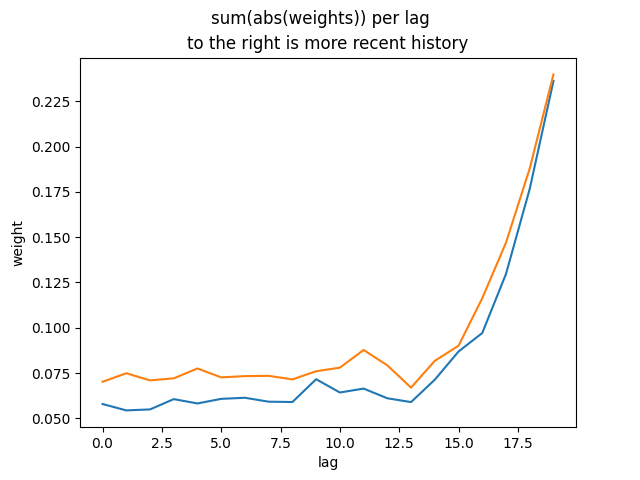

In [757]:
fig, ax = plt.subplots()
ax.plot(h1_col)
ax.plot(h2_col)
fig.suptitle('sum(abs(weights)) per lag')
ax.set_title('to the right is more recent history')
ax.set_ylabel('weight')
ax.set_xlabel('lag')

In [758]:
pre=100
post=50
binsize=5
nlags=20
num_PCs=20

laser_bounds, ctrl_bounds = session.adjustLaserBounds(pre, post, only_climb=True)
if session.num_powers==5:
    power_mask = session.getPowers(bounds=laser_bounds, num_powers=5, 
                                   pre=pre, post=post)
    omit_lasers = laser_bounds[power_mask<4,:]
    laser_bounds = laser_bounds[power_mask>=4,:]
else:
    power_mask = session.getPowers(bounds=laser_bounds, num_powers=2, 
                                   pre=pre, post=post)
    omit_lasers = laser_bounds[power_mask==1,:]
    laser_bounds = laser_bounds[power_mask==2,:]

omitLaserBounds = omitBoundInBounds(session.climbing_bounds, omit_lasers)
omitLaserBounds = omitBoundInBounds(omitLaserBounds, ctrl_bounds)
omitLaserBounds = minimumBoundSize(omitLaserBounds, min_size = post+pre) 

(X, Y), PCs = session.generate_trainset(bounds=omitLaserBounds, binsize=binsize, nlags=nlags, num_PCs=num_PCs)
X_laser, Y_laser = session.generate_testset(PCs, laser_bounds, binsize=binsize, nlags=nlags, num_PCs=num_PCs)
X_ctrl, Y_ctrl = session.generate_testset(PCs, ctrl_bounds, binsize=binsize, nlags=nlags, num_PCs=num_PCs)

In [759]:
h_sw = sw_harray[swmax,:,:]
h_c = c_harray[cmax,:,:]
h_l = l_harray[lmax,:,:]

In [760]:
yhat_l1, yhat_l2 = split_h_predics(X_laser, h_sw, nlags=nlags, num_region1=20)
yhat_c1, yhat_c2 = split_h_predics(X_ctrl, h_sw, nlags=nlags, num_region1=20)

this h has bias
this h has bias


In [761]:
yhat_l1_reshape = np.reshape(yhat_l1, (int(yhat_l1.shape[0]/16),16, yhat_l1.shape[1]))
yhat_l2_reshape = np.reshape(yhat_l2, (int(yhat_l2.shape[0]/16),16, yhat_l2.shape[1]))
ylaser_reshape = np.reshape(Y_laser, (int(Y_laser.shape[0]/16),16, Y_laser.shape[1]))


In [762]:
yhat1_avg = np.average(yhat_l1_reshape, axis=0)
yhat2_avg = np.average(yhat_l2_reshape, axis=0)
ylaser_avg = np.average(ylaser_reshape, axis=0)

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


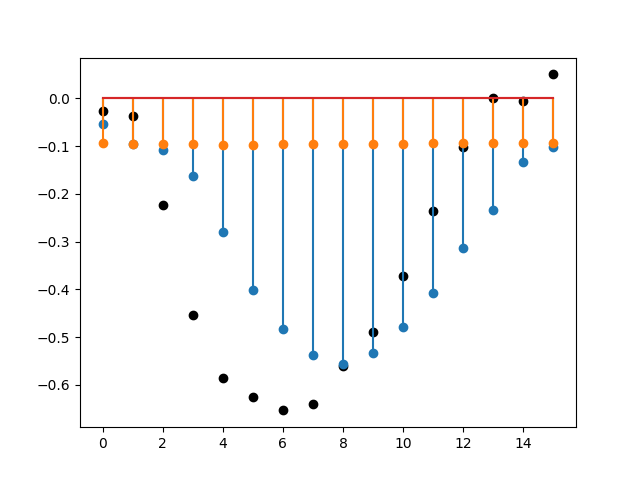

In [763]:
fig, ax = plt.subplots()
ax.stem(np.arange(16), yhat1_avg[:,0])
ax.stem(np.arange(16), yhat2_avg[:,0], linefmt='tab:orange')
ax.scatter(np.arange(16), ylaser_avg[:,0], color='black')

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


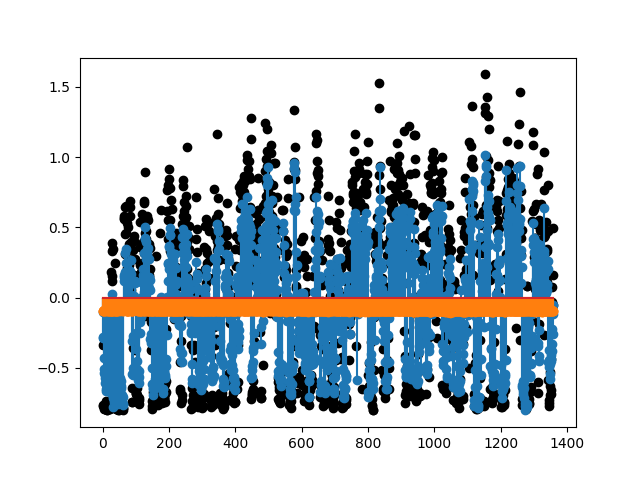

In [764]:
fig, ax = plt.subplots()
ax.stem(np.arange(yhat_c1.shape[0]), yhat_c1[:,0])
ax.stem(np.arange(yhat_c2.shape[0]), yhat_c2[:,0], linefmt='tab:orange')
ax.scatter(np.arange(Y_ctrl.shape[0]), Y_ctrl[:,0], color='black')

/tmp/ipykernel_6321/3118899073.py:1: RuntimeWarning: invalid value encountered in log10
  yhat_lratio = np.log10(np.divide(yhat_l1, yhat_l2))
/tmp/ipykernel_6321/3118899073.py:2: RuntimeWarning: invalid value encountered in log10
  yhat_cratio = np.log10(np.divide(yhat_c1, yhat_c2))
/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


(array([0.00976201, 0.004881  , 0.01464301, 0.03416703, 0.05369105,
        0.13178711, 0.17571615, 0.45881439, 0.67357858, 1.93287766]),
 array([-1.92672846, -1.64018878, -1.35364909, -1.06710941, -0.78056973,
        -0.49403004, -0.20749036,  0.07904932,  0.36558901,  0.65212869,
         0.93866837]),
 <BarContainer object of 10 artists>)

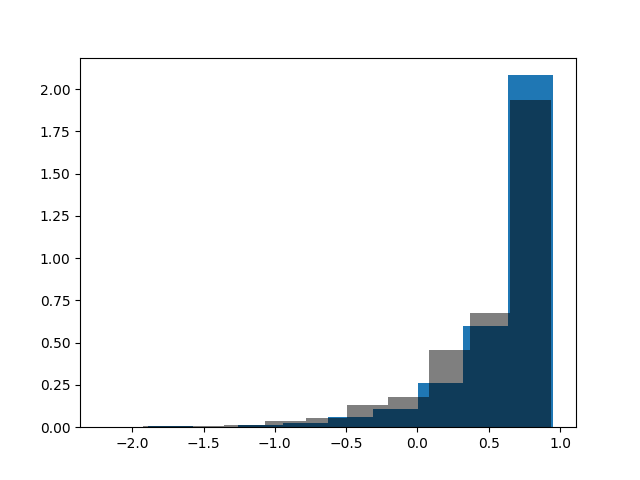

In [765]:
yhat_lratio = np.log10(np.divide(yhat_l1, yhat_l2))
yhat_cratio = np.log10(np.divide(yhat_c1, yhat_c2))
fig, ax = plt.subplots()
ax.hist(yhat_lratio[:,0], color='tab:blue', density=True, stacked=True,)
#ax.set_xlim(-2,1)
ax.hist(yhat_cratio[:,0], color='black', density=True, stacked=True, alpha=.5)
